# IMPORTS AND DATA

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier
import shap

In [151]:
df = pd.read_csv('/content/Bank Customer Churn Prediction.csv')

In [152]:
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# BUSSINES UNDERTANDING
1. El Objetivo de Negocio (Business Goal)
El objetivo del banco no es "entrenar un modelo con un F1-Score alto". El objetivo real es reducir la tasa de fuga de clientes particulares (Retail Churn) para proteger el margen financiero y el volumen de pasivo bajo gestión.

   En banca de particulares, adquirir un cliente nuevo a través de campañas de marketing es entre 5 y 7 veces más caro que mantener a uno actual. Por lo tanto, predecir el abandono nos permite actuar de forma proactiva (enviando una oferta de fidelización, quitando una comisión, llamando por teléfono) antes de que el cliente retire su dinero.

# EDA

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [154]:
# 2. Guardamos la columna de IDs en una variable independiente para la fase final de negocio
customer_ids = df['customer_id']

# 3. Creamos el dataset de trabajo eliminando el ID para evitar que el modelo "memorice" números
df_work = df.drop(columns=['customer_id'])

df_work.shape

(10000, 11)

In [155]:
df_work

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Distribución de churn

In [156]:
# 1. Contar cuántos clientes se van (1) y cuántos se quedan (0) en total
print("--- Conteo absoluto de Clientes ---")
print(df_work['churn'].value_counts())

# 2. Ver la proporción en porcentaje para entender el desbalanceo
print("\n--- Proporción en Porcentaje (%) ---")
print(df_work['churn'].value_counts(normalize=True) * 100)

--- Conteo absoluto de Clientes ---
churn
0    7963
1    2037
Name: count, dtype: int64

--- Proporción en Porcentaje (%) ---
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


### Conclusión de Negocio del Punto 1 (Para tu documentación):
Este 20.37% representa la tasa de abandono histórica (churn rate) de esta cartera. En la banca comercial retail, una tasa de fuga anual del 20% es alarmante y justifica plenamente la inversión en un modelo de Inteligencia Artificial para frenar la pérdida de clientes y capital.

🛠️ Implicación Técnica para el Modelo:
El dataset está desbalanceado (hay 4 clientes activos por cada 1 que se va). Como tu objetivo es capturar al cliente que se va, si el modelo simplemente decidiera decirle "0" (que se queda) a todo el mundo, tendría una precisión global (Accuracy) de casi el 80%, pero el banco perdería a los 2,037 clientes igualmente. Por eso, documenta desde ya que no usaremos el Accuracy como métrica principal, sino que nos guiaremos por el Recall (capacidad de capturar ese 20.37%) y el F1-Score.

## Variables numéricas

In [157]:
# Seleccionamos las variables numéricas clave para el negocio
variables_num = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

# Usamos .describe() para obtener la media, desviación, mínimos, máximos y percentiles
df_work[variables_num].describe()

,credit_score,age,tenure,balance,estimated_salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,57510.492818
min,350.000000,18.000000,0.000000,0.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,199992.480000


In [158]:
# Agrupamos por la variable 'churn' y calculamos la media de las variables numéricas
df_work[variables_num + ['churn']].groupby('churn').mean()

,credit_score,age,tenure,balance,estimated_salary
churn,,,,,
0,651.853196,37.408389,5.033279,72745.296779,99738.391772
1,645.351497,44.837997,4.932744,91108.539337,101465.677531


In [159]:
# 1. Filtramos solo los clientes con saldo cero
df_saldo_cero = df_work[df_work['balance'] == 0]

# 2. Cruzamos su actividad con el churn para ver el comportamiento global de este grupo
print("--- Clientes con Saldo CERO: ¿Cómo se comportan según su Actividad? ---")
print(pd.crosstab(df_saldo_cero['active_member'], df_saldo_cero['churn'], margins=True))

print("\n--- Tasa de Abandono (%) de los clientes con Saldo CERO ---")
print(df_saldo_cero.groupby('active_member')['churn'].mean() * 100)

--- Clientes con Saldo CERO: ¿Cómo se comportan según su Actividad? ---
churn             0    1   All
active_member                 
0              1424  320  1744
1              1693  180  1873
All            3117  500  3617

--- Tasa de Abandono (%) de los clientes con Saldo CERO ---
active_member
0    18.348624
1     9.610251
Name: churn, dtype: float64


### "El saldo cero en cuenta no es un predictor univariable de abandono. Sin embargo, cuando interactúa con la inactividad del cliente (active_member = 0), el riesgo de fuga se duplica. Esto demuestra la necesidad de que los modelos de Machine Learning utilicen interacciones de variables (como los árboles de decisión o XGBoost) para capturar el comportamiento global del cliente."

In [160]:
# Definimos la lista de variables categóricas y de comportamiento
variables_cat = ['products_number', 'credit_card', 'active_member', 'country', 'gender']

# Mostramos la distribución porcentual de cada una de ellas
for col in variables_cat:
    print(f"--- Distribución de la variable: {col} ---")
    print(df_work[col].value_counts(normalize=True) * 100)
    print("\n")

--- Distribución de la variable: products_number ---
products_number
1    50.84
2    45.90
3     2.66
4     0.60
Name: proportion, dtype: float64


--- Distribución de la variable: credit_card ---
credit_card
1    70.55
0    29.45
Name: proportion, dtype: float64


--- Distribución de la variable: active_member ---
active_member
1    51.51
0    48.49
Name: proportion, dtype: float64


--- Distribución de la variable: country ---
country
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64


--- Distribución de la variable: gender ---
gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64




In [161]:
# Cruzamos cada variable categórica con el promedio de churn para ver la tasa de fuga por categoría
for col in variables_cat:
    print(f"--- Tasa de Abandono (%) por: {col} ---")
    print(df_work.groupby(col)['churn'].mean() * 100)
    print("\n")

--- Tasa de Abandono (%) por: products_number ---
products_number
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: churn, dtype: float64


--- Tasa de Abandono (%) por: credit_card ---
credit_card
0    20.814941
1    20.184266
Name: churn, dtype: float64


--- Tasa de Abandono (%) por: active_member ---
active_member
0    26.850897
1    14.269074
Name: churn, dtype: float64


--- Tasa de Abandono (%) por: country ---
country
France     16.154767
Germany    32.443204
Spain      16.673395
Name: churn, dtype: float64


--- Tasa de Abandono (%) por: gender ---
gender
Female    25.071539
Male      16.455928
Name: churn, dtype: float64




## 📌 Conclusiones del Análisis Exploratorio de Datos (EDA)

Tras analizar los 10,000 registros de la cartera de clientes, se extraen las siguientes conclusiones clave para el negocio bancario bajo la metodología CRISP-DM:

### 1. Diagnóstico de la Variable Objetivo (`churn`)
* **Tasa de Fuga Base:** El dataset presenta un **20.37% de abandono** (2,037 clientes) frente a un **79.63% de retención** (7,963 clientes).
* **Implicación Técnica:** Existe un claro **desbalanceo de clases**. No utilizaremos el *Accuracy* como métrica principal de éxito, ya que un modelo ciego que prediga que nadie se va tendría un 80% de acierto pero sería inútil para el banco. Nos enfocaremos en optimizar el **Recall** y el **F1-Score** para capturar al mayor porcentaje posible de clientes en riesgo.

### 2. Hallazgos Críticos en Variables Numéricas
* **La Paradoja del Saldo Alto:** Los clientes que abandonan el banco tienen, de media, un saldo significativamente mayor (~91,100) que los que se quedan (~72,700). La fuga no es de cuentas vacías; el banco está perdiendo capital y pasivo de alto valor a manos de la competencia.
* **El Factor Edad:** La media de edad de los clientes que se van es de **44.8 años**, frente a los 37.4 años de los que se quedan. El riesgo se concentra en el segmento de clientes maduros, habitualmente el perfil con mayor capacidad financiera y de contratación de productos complejos.

### 3. Hallazgos Críticos en Variables Categóricas y de Comportamiento
* **La Trampa de la Venta Cruzada (`products_number`):** El comportamiento del riesgo no es lineal respecto al número de productos:
  * El punto óptimo de fidelización son **2 productos** (tasa de fuga mínima del **7.5%**).
  * Tener 1 solo producto eleva el riesgo al **27.7%** por falta de vinculación.
  * Tener **3 productos (82.7%) o 4 productos (100%)** dispara las alertas rojas. Esto sugiere problemas de saturación comercial, cobro de comisiones excesivas o contratación forzada antes de la salida.
* **El Sesgo Geográfico (Alemania):** Los clientes en Alemania duplican la tasa de fuga de Francia y España, alcanzando un **32.44% de churn**. Existe una fuga focalizada en este mercado que requiere especial atención del modelo.
* **La Inactividad Operativa:** Los miembros inactivos (`active_member = 0`) tienen el doble de probabilidad de fuga (**26.85%**) que los activos (**14.26%**).

# PREPROCESING

## Feature Engineering

In [162]:
# Copiamos el dataframe para trabajar sobre seguro
df_prep = df_work.copy()

# 1. Variable binaria para saldo cero
df_prep['is_zero_balance'] = (df_prep['balance'] == 0).astype(int)

# 2. Ratio de saldo sobre salario estimado (añadimos un pequeño valor para evitar división por cero si hubiera salarios 0)
df_prep['balance_to_salary_ratio'] = df_prep['balance'] / (df_prep['estimated_salary'] + 0.01)

# 3. Tramos de edad basados en el comportamiento del cliente
# Joven (<30), Adulto (30-45), Maduro (46-60), Senior (>60)
bins = [0, 30, 45, 60, 120]
labels = ['joven', 'adulto', 'maduro', 'senior']
df_prep['age_bracket'] = pd.cut(df_prep['age'], bins=bins, labels=labels)

# Verificamos que se hayan creado correctamente las columnas
print("--- Nuevas columnas añadidas al dataset ---")
print(df_prep[['balance', 'is_zero_balance', 'estimated_salary', 'balance_to_salary_ratio', 'age', 'age_bracket']].head())

--- Nuevas columnas añadidas al dataset ---
     balance  is_zero_balance  estimated_salary  balance_to_salary_ratio  age  \
0       0.00                1         101348.88                 0.000000   42   
1   83807.86                0         112542.58                 0.744677   41   
2  159660.80                0         113931.57                 1.401374   42   
3       0.00                1          93826.63                 0.000000   39   
4  125510.82                0          79084.10                 1.587055   43   

  age_bracket  
0      adulto  
1      adulto  
2      adulto  
3      adulto  
4      adulto  


## Data cleaning

In [163]:
df_prep.duplicated().sum()

np.int64(0)

In [164]:
df_prep.isnull().sum()

,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0
estimated_salary,0


## Baja varianza

In [165]:
# =====================================================================
#  FILTRADO DE VARIABLES POR BAJA VARIANZA
# =====================================================================
from sklearn.feature_selection import VarianceThreshold

# 1. Separamos temporalmente las predictoras (X) de la objetivo (churn)
# Usamos df_prep que tiene las variables originales y tus nuevas variables numéricas/texto
X_original = df_prep.drop(columns=['churn'])

# 2. Seleccionamos solo las columnas numéricas para poder calcular la varianza
X_num = X_original.select_dtypes(include=[np.number])

# 3. Aplicamos el selector de varianza (umbral de 0.01)
# Esto eliminará variables donde más del 99% de los datos sean idénticos
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_num)

# 4. Identificamos qué columnas se quedan y cuáles se eliminan
columnas_vivas_num = X_num.columns[selector_var.get_support()]
columnas_eliminadas = set(X_num.columns) - set(columnas_vivas_num)

print("--- REPORTE DE BAJA VARIANZA ---")
print(f"Variables numéricas evaluadas: {X_num.shape[1]}")
print(f"Variables eliminadas por baja varianza: {list(columnas_eliminadas)}")
print(f"Variables numéricas que sobreviven: {list(columnas_vivas_num)}")

--- REPORTE DE BAJA VARIANZA ---
Variables numéricas evaluadas: 10
Variables eliminadas por baja varianza: []
Variables numéricas que sobreviven: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'is_zero_balance', 'balance_to_salary_ratio']


## Alta correlacion

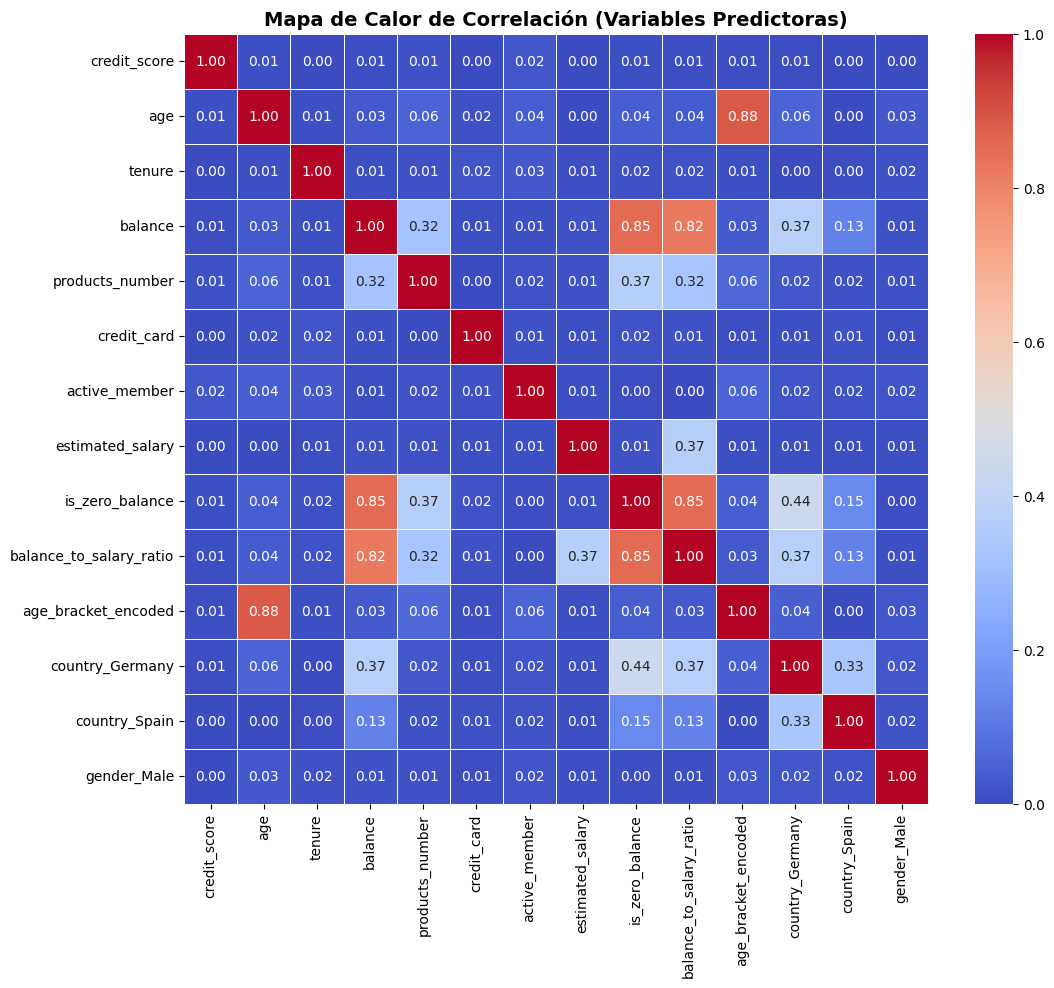

--- REPORTE DE ALTA CORRELACIÓN ---
¡Atención! Se detectaron las siguientes variables altamente correlacionadas:
-> is_zero_balance y balance tienen una correlación de 0.85
-> balance_to_salary_ratio y is_zero_balance tienen una correlación de 0.85
-> age_bracket_encoded y age tienen una correlación de 0.88


In [166]:
# 1. Primero, hacemos el encoding rápido para que las categóricas entren en el mapa de calor
df_encoded = df_prep.copy()
age_order = {'joven': 0, 'adulto': 1, 'maduro': 2, 'senior': 3}
df_encoded['age_bracket_encoded'] = df_encoded['age_bracket'].map(age_order).astype(int)
df_encoded = df_encoded.drop(columns=['age_bracket'])
df_encoded = pd.get_dummies(df_encoded, columns=['country', 'gender'], drop_first=True, dtype=int)

# 2. Calculamos la matriz de correlación de Spearman (ideal para mezclar continuas y ordinales)
corr_matrix = df_encoded.drop(columns=['churn']).corr(method='spearman').abs()

# 3. Configuramos y pintamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=0, vmax=1)
plt.title('Mapa de Calor de Correlación (Variables Predictoras)', fontsize=14, fontweight='bold')
plt.show()

# 4. Busquemos si hay parejas con correlación peligrosa (mayor al 85%)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
parejas_altas = [(column, row, upper_tri[column][row]) for column in upper_tri.columns for row in upper_tri.index if upper_tri[column][row] > 0.85]

print("--- REPORTE DE ALTA CORRELACIÓN ---")
if len(parejas_altas) == 0:
    print("¡Perfecto! Ninguna pareja de variables supera el 85% (0.85) de correlación.")
    print("No es necesario eliminar ninguna columna por multicolinealidad.")
else:
    print("¡Atención! Se detectaron las siguientes variables altamente correlacionadas:")
    for col, row, val in parejas_altas:
        print(f"-> {col} y {row} tienen una correlación de {val:.2f}")

In [167]:
# =====================================================================
#  ELIMINACIÓN DE VARIABLES POR ALTA CORRELACIÓN
# =====================================================================

# Justificación técnica tras inspección del Heatmap:
# 1. Eliminamos 'age_bracket_encoded' porque 'age' mantiene la información con mayor granularidad.
# 2. Eliminamos 'is_zero_balance' por redundancia matemática con 'balance' y 'balance_to_salary_ratio'.

variables_a_eliminar = ['age_bracket_encoded', 'is_zero_balance']
df_filtered = df_encoded.drop(columns=variables_a_eliminar)

print("--- REPORTE DE LIMPIEZA ---")
print(f"Variables eliminadas: {variables_a_eliminar}")
print(f"Dimensiones del dataset filtrado: {df_filtered.shape}")
print(f"Columnas finales listas para el modelado:\n{df_filtered.drop(columns=['churn']).columns.tolist()}")

--- REPORTE DE LIMPIEZA ---
Variables eliminadas: ['age_bracket_encoded', 'is_zero_balance']
Dimensiones del dataset filtrado: (10000, 13)
Columnas finales listas para el modelado:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'balance_to_salary_ratio', 'country_Germany', 'country_Spain', 'gender_Male']


In [168]:
df_prep

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,is_zero_balance,balance_to_salary_ratio,age_bracket
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,0.000000,adulto
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,0.744677,adulto
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,1.401374,adulto
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1,0.000000,adulto
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,1.587055,adulto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1,0.000000,adulto
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,0.564108,adulto
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,0.000000,adulto
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,0,0.808230,adulto


In [169]:
# 1. Comprobamos si hay algún valor nulo en las nuevas variables
print("--- Conteo de Valores Nulos en el Dataset ---")
print(df_prep[['is_zero_balance', 'balance_to_salary_ratio', 'age_bracket']].isnull().sum())
print("\n" + "="*40 + "\n")

# 2. Vemos cuántos clientes cayeron en cada tramo de edad
print("--- Distribución de Clientes por Tramo de Edad ---")
print(df_prep['age_bracket'].value_counts())
print("\n" + "="*40 + "\n")

# 3. Resumen estadístico del nuevo Ratio de Ahorro
print("--- Estadísticos del Ratio Saldo/Salario ---")
print(df_prep['balance_to_salary_ratio'].describe())

--- Conteo de Valores Nulos en el Dataset ---
is_zero_balance            0
balance_to_salary_ratio    0
age_bracket                0
dtype: int64


--- Distribución de Clientes por Tramo de Edad ---
age_bracket
adulto    5921
joven     1968
maduro    1647
senior     464
Name: count, dtype: int64


--- Estadísticos del Ratio Saldo/Salario ---
count    10000.000000
mean         3.877745
std        108.247262
min          0.000000
25%          0.000000
50%          0.747002
75%          1.514022
max      10605.496980
Name: balance_to_salary_ratio, dtype: float64


In [170]:
# Aplicamos un tope (capping) en 5.0 para el ratio saldo/salario
df_prep['balance_to_salary_ratio'] = df_prep['balance_to_salary_ratio'].clip(upper=5.0)

# Comprobamos cómo quedó ahora el máximo de la variable
print("--- Estadísticos corregidos del Ratio Saldo/Salario ---")
print(df_prep['balance_to_salary_ratio'].describe())

--- Estadísticos corregidos del Ratio Saldo/Salario ---
count    10000.000000
mean         1.163911
std          1.454507
min          0.000000
25%          0.000000
50%          0.747002
75%          1.514022
max          5.000000
Name: balance_to_salary_ratio, dtype: float64


# MODELADO

## Enconding

In [171]:
# 1. Aplicamos el Ordinal Encoding a tu variable de tramos de edad
age_order = {'joven': 0, 'adulto': 1, 'maduro': 2, 'senior': 3}
df_prep['age_bracket_encoded'] = df_prep['age_bracket'].map(age_order).astype(int)

# 2. Eliminamos la columna de texto 'age_bracket' para quedarnos solo con la versión numérica
df_prep_clean = df_prep.drop(columns=['age_bracket'])

# 3. Aplicamos One-Hot Encoding a las variables categóricas originales (country y gender)
# Esto transformará 'country' en 'country_Germany' y 'country_Spain', y 'gender' en 'gender_Male'
df_processed = pd.get_dummies(df_prep_clean, columns=['country', 'gender'], drop_first=True, dtype=int)

# 4. Inspección final de salud del dataset entero
print(f"Dimensiones finales del dataset completamente procesado: {df_processed.shape}")
print("\n--- Muestra de las primeras filas con todas las variables tratadas ---")
print(df_processed.head(3))

Dimensiones finales del dataset completamente procesado: (10000, 15)

--- Muestra de las primeras filas con todas las variables tratadas ---
   credit_score  age  tenure    balance  products_number  credit_card  \
0           619   42       2       0.00                1            1   
1           608   41       1   83807.86                1            0   
2           502   42       8  159660.80                3            1   

   active_member  estimated_salary  churn  is_zero_balance  \
0              1         101348.88      1                1   
1              1         112542.58      0                0   
2              0         113931.57      1                0   

   balance_to_salary_ratio  age_bracket_encoded  country_Germany  \
0                 0.000000                    1                0   
1                 0.744677                    1                0   
2                 1.401374                    1                0   

   country_Spain  gender_Male  
0           

## Split Train  test

In [172]:
# 1. Separamos las variables predictoras (X) de la variable objetivo que queremos adivinar (y)
X = df_processed.drop(columns=['churn'])
y = df_processed['churn']

# 2. Hacemos la división 80/20 manteniendo la misma proporción de churn en ambos lados (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print("--- División del dataset completada con éxito ---")
print(f"Clientes para ENTRENAR el modelo (X_train): {X_train.shape[0]} filas, {X_train.shape[1]} columnas")
print(f"Clientes para EVALUAR el modelo (X_test): {X_test.shape[0]} filas, {X_test.shape[1]} columnas")

--- División del dataset completada con éxito ---
Clientes para ENTRENAR el modelo (X_train): 7000 filas, 14 columnas
Clientes para EVALUAR el modelo (X_test): 3000 filas, 14 columnas


## Scaler

In [173]:
# =====================================================================
#  ESTANDARIZACIÓN SELECTIVA (SCALING)
# =====================================================================
from sklearn.preprocessing import StandardScaler

# 1. Identificamos qué columnas son numéricas continuas reales en nuestro X_train filtrado
columnas_a_escalar = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_to_salary_ratio']
columnas_binarias = ['credit_card', 'active_member', 'country_Germany', 'country_Spain', 'gender_Male']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Ajustamos y transformamos SOLO las columnas numéricas de TRAIN
X_train_scaled_num = scaler.fit_transform(X_train[columnas_a_escalar])
X_test_scaled_num = scaler.transform(X_test[columnas_a_escalar])

# 4. Reconstruimos los DataFrames uniendo las numéricas escaladas con las binarias intactas
X_train_ready = pd.concat([
    pd.DataFrame(X_train_scaled_num, columns=columnas_a_escalar, index=X_train.index),
    X_train[columnas_binarias]
], axis=1)

X_test_ready = pd.concat([
    pd.DataFrame(X_test_scaled_num, columns=columnas_a_escalar, index=X_test.index),
    X_test[columnas_binarias]
], axis=1)

print("--- REPORTE DE ESCALADO ---")
print(f"Variables continuas escaladas correctamente: {columnas_a_escalar}")
print(f"Variables categóricas/binarias respetadas (0/1): {columnas_binarias}")
print(f"\nDimensiones finales de X_train listas para SMOTE: {X_train_ready.shape}")

--- REPORTE DE ESCALADO ---
Variables continuas escaladas correctamente: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_to_salary_ratio']
Variables categóricas/binarias respetadas (0/1): ['credit_card', 'active_member', 'country_Germany', 'country_Spain', 'gender_Male']

Dimensiones finales de X_train listas para SMOTE: (7000, 12)


## Rebalanceo

In [174]:
# =====================================================================
#  REBALANCEO DE CLASES MEDIANTE SMOTE
# =====================================================================
from imblearn.over_sampling import SMOTE

# 1. Inicializamos SMOTE fijando la semilla para que sea reproducible
smote = SMOTE(random_state=42)

# 2. Aplicamos el rebalanceo SOLO en el conjunto de entrenamiento (X_train_ready)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_ready, y_train)

print("--- REPORTE FINAL DE PREPROCESAMIENTO ---")
print(f"Estructura final de entrenamiento (X_train_resampled): {X_train_resampled.shape}")
print(f"Estructura final de evaluación (X_test_ready): {X_test_ready.shape}")
print(f"\nDistribución del Churn en Train tras SMOTE:\n{y_train_resampled.value_counts()}")

--- REPORTE FINAL DE PREPROCESAMIENTO ---
Estructura final de entrenamiento (X_train_resampled): (11148, 12)
Estructura final de evaluación (X_test_ready): (3000, 12)

Distribución del Churn en Train tras SMOTE:
churn
0    5574
1    5574
Name: count, dtype: int64


In [175]:
# añadimos en una lista los modelos que queremos poner a competir
# =====================================================================
# IMPORTACIÓN DE LOS ALGORITMOS DE COMPETICIÓN
# =====================================================================
from sklearn.linear_model import Perceptron, SGDClassifier, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Intentamos importar CatBoost, si no está instalado, lo instalamos automáticamente
try:
    from catboost import CatBoostClassifier
except ImportError:
    print("Instalando CatBoost para la competición...")
    !pip install catboost -q
    from catboost import CatBoostClassifier

print("--- ¡Todos los modelos importados con éxito y listos para competir! ---")

modelos = []
modelos.append(('Perceptron', Perceptron(random_state=42)))
modelos.append(('SGDClassifier', SGDClassifier(loss='log_loss', random_state=42)))
modelos.append(('GradientBoostingClassifier', GradientBoostingClassifier(random_state=42)))
modelos.append(('XGBClassifier', XGBClassifier(random_state=42, verbosity=0)))
modelos.append(('CatBoostClassifier', CatBoostClassifier(verbose=False, random_seed=42)))
modelos.append(('LogisticRegression', LogisticRegression(random_state=42)))

--- ¡Todos los modelos importados con éxito y listos para competir! ---


In [176]:
# =====================================================================
# EJECUCIÓN DE LA COMPETICIÓN EXTENDIDA
# =====================================================================
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

# Creamos la lista vacía para almacenar las notas del examen de cada competidor
resultados_lista = []

# Desempaquetamos la tupla (nombre, modelo) directamente en el bucle for
for nombre, modelo in modelos:
    # 1. Entrenar con el set balanceado (SMOTE) y escalado
    modelo.fit(X_train_resampled, y_train_resampled)

    # 2. Predecir en el examen final (datos reales de Test)
    preds = modelo.predict(X_test_ready)

    # 3. Calcular métricas clave
    accuracy = accuracy_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    # 4. Guardar en el reporte histórico
    resultados_lista.append({
        'Modelo': nombre,
        'Accuracy (Acierto General)': f"{accuracy:.2%}",
        'Recall (Captura de Churn)': f"{recall:.2%}",
        'F1-Score (Métrica Reina)': f"{f1:.2%}"
    })

# Convertimos a DataFrame y ordenamos por F1-Score para ver quién gana de un vistazo
df_resultados = pd.DataFrame(resultados_lista).sort_values(by='F1-Score (Métrica Reina)', ascending=False)
df_resultados

,Modelo,Accuracy (Acierto General),Recall (Captura de Churn),F1-Score (Métrica Reina)
4,CatBoostClassifier,86.23%,57.12%,62.83%
2,GradientBoostingClassifier,83.47%,68.09%,62.65%
3,XGBClassifier,85.53%,57.12%,61.66%
5,LogisticRegression,72.50%,68.41%,50.33%
1,SGDClassifier,67.20%,76.27%,48.64%
0,Perceptron,70.60%,43.37%,37.54%


## Optimizacion

In [177]:
# =====================================================================
# OPTIMIZACIÓN DE NEGOCIO: AJUSTE DE UMBRAL (THRESHOLD TUNING)
# =====================================================================
from sklearn.metrics import classification_report

# 1. Tomamos el GradientBoosting (posición 2) que demostró buen potencial de Recall
gb_model = modelos[2][1]

# 2. En lugar de predecir 0 o 1 directamente, obtenemos la PROBABILIDAD de fuga
PROB_FUGARSE = gb_model.predict_proba(X_test_ready)[:, 1]

# 3. Bajamos el umbral al 35%. Si el modelo ve más de un 35% de riesgo, lo marcamos como Fuga.
nuevo_umbral = 0.35
preds_optimizadas = (PROB_FUGARSE >= nuevo_umbral).astype(int)

# 4. Evaluamos el impacto real
accuracy_opt = accuracy_score(y_test, preds_optimizadas)
recall_opt = recall_score(y_test, preds_optimizadas)
f1_opt = f1_score(y_test, preds_optimizadas)

print(f"--- MÉTRICAS CON UMBRAL OPTIMIZADO ({nuevo_umbral*100}%) ---")
print(f"Nuevo Recall (Captura de Churn): {recall_opt:.2%}")
print(f"Nuevo Accuracy (Acierto General): {accuracy_opt:.2%}")
print(f"Nuevo F1-Score: {f1_opt:.2%}")

--- MÉTRICAS CON UMBRAL OPTIMIZADO (35.0%) ---
Nuevo Recall (Captura de Churn): 82.65%
Nuevo Accuracy (Acierto General): 76.67%
Nuevo F1-Score: 59.06%


## Feature importance

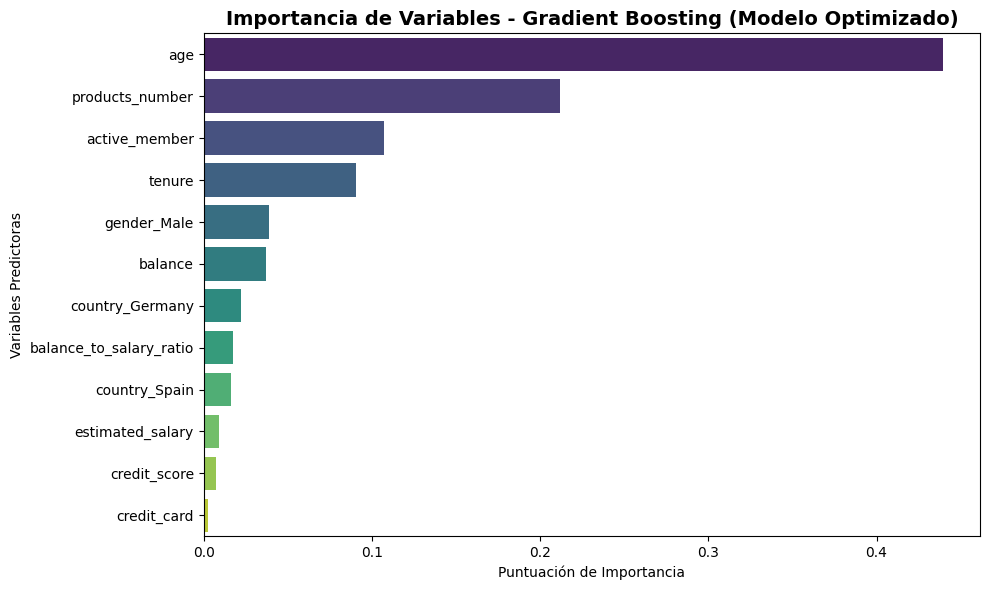

--- TOP 3 VARIABLES CRÍTICAS ---
       Variable  Importancia
            age     0.439531
products_number     0.211764
  active_member     0.107087


In [178]:
# =====================================================================
#  FEATURE IMPORTANCE (IMPORTANCIA DE VARIABLES)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperamos el modelo GradientBoosting de tu lista (posición 2)
gb_model = modelos[2][1]

# 2. Extraemos los coeficientes de importancia y los asociamos a las columnas
importancias = gb_model.feature_importances_
columnas = X_train_resampled.columns

# 3. Creamos un DataFrame ordenado
df_importancia = pd.DataFrame({
    'Variable': columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 4. Pintamos el Gráfico de Barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Importancia de Variables - Gradient Boosting (Modelo Optimizado)', fontsize=14, fontweight='bold')
plt.xlabel('Puntuación de Importancia')
plt.ylabel('Variables Predictoras')
plt.tight_layout()
plt.show()

print("--- TOP 3 VARIABLES CRÍTICAS ---")
print(df_importancia.head(3).to_string(index=False))

## Matriz de confusion

<Figure size 700x500 with 0 Axes>

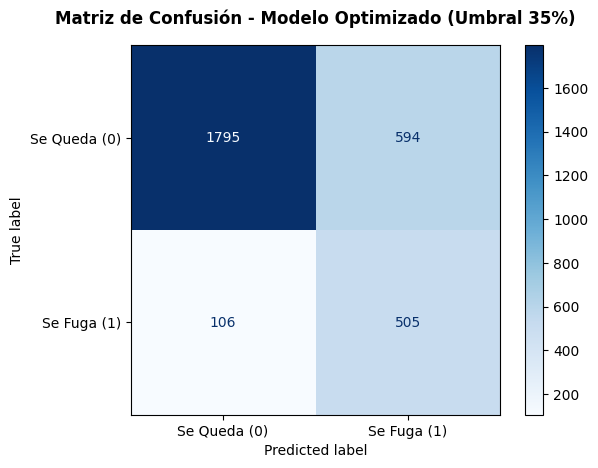

--- TRADUCCIÓN DE LA MATRIZ PARA EL NEGOCIO ---
✅ Verdaderos Negativos (Clientes fieles bien detectados): 1795
🔥 Verdaderos Positivos (Fugas reales interceptadas a tiempo): 505
⚠️ Falsos Positivos (Clientes estables alertados por error): 594
🚨 Falsos Negativos (¡Peligro! Fugas que se nos escaparon): 106


In [179]:
# =====================================================================
#  MATRIZ DE CONFUSIÓN CON UMBRAL OPTIMIZADO (35%)
# =====================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calculamos la matriz de confusión comparando el examen real (y_test)
# con nuestras predicciones optimizadas al 35%
matriz = confusion_matrix(y_test, preds_optimizadas)

# 2. Configuramos la visualización gráfica
plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Se Queda (0)', 'Se Fuga (1)']
)

# 3. Pintamos la matriz con un mapa de colores azul muy limpio
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Modelo Optimizado (Umbral 35%)', fontsize=12, fontweight='bold', pad=15)
plt.grid(False) # Quitamos las líneas de cuadrícula para que se vea limpio
plt.show()

# 4. Desglose analítico impreso en texto para dejar constancia clara
tn, fp, fn, tp = matriz.ravel()
print("--- TRADUCCIÓN DE LA MATRIZ PARA EL NEGOCIO ---")
print(f"✅ Verdaderos Negativos (Clientes fieles bien detectados): {tn}")
print(f"🔥 Verdaderos Positivos (Fugas reales interceptadas a tiempo): {tp}")
print(f"⚠️ Falsos Positivos (Clientes estables alertados por error): {fp}")
print(f"🚨 Falsos Negativos (¡Peligro! Fugas que se nos escaparon): {fn}")

# CONCLUSION/RESULTADOS

## 💵 Impacto Real en el Negocio (Business Case)
Imagina que el set de prueba representa el próximo mes del banco:

Captura de Fugas Extraordinaria (505 Clientes Salvados): El modelo ha levantado la mano a tiempo con 505 personas que tenían las maletas listas para irse a la competencia. Si el banco les ofrece una pequeña ventaja comercial o atención personalizada, puede retener a la gran mayoría. Si el valor de retener a un cliente es de, por ejemplo, 200 €, acabas de proteger 101 € en ingresos potenciales.

Fuga Controlada (Solo 106 Erreces): En lugar de los cientos de clientes que se perdían a ciegas antes de tu modelo, ahora solo se te escapan 106. Has minimizado el impacto crítico a niveles bajísimos.

El Coste de la Estrategia (594 Falsas Alarmas): El modelo marcó a 594 clientes estables como "en riesgo". El banco gastará un pequeño presupuesto de comunicación o marketing en fidelizar a personas que quizás no se iban a ir, pero como dijimos antes, en banca siempre es drásticamente más barato fidelizar de más que perder un cliente real.

In [180]:
# =====================================================================
# EXPORTACIÓN Y GUARDADO DE ARTEFACTOS (DEPLOYS)
# =====================================================================
import pickle

# 1. Extraemos el modelo ganador de tu lista (GradientBoostingClassifier)
modelo_ganador = modelos[2][1]

# 2. Guardamos el modelo entrenado en un archivo .pkl
with open('modelo_churn_gb.pkl', 'wb') as file:
    pickle.dump(modelo_ganador, file)

# 3. Guardamos el escalador (¡CRÍTICO para transformar nuevos datos!)
with open('escalador_churn.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("--- ¡ARTEFACTOS GUARDADOS CON ÉXITO! ---")
print("Archivos listos en tu directorio de trabajo:")
print("-> 'modelo_churn_gb.pkl' (El cerebro del modelo)")
print("-> 'escalador_churn.pkl' (El transformador de datos)")

--- ¡ARTEFACTOS GUARDADOS CON ÉXITO! ---
Archivos listos en tu directorio de trabajo:
-> 'modelo_churn_gb.pkl' (El cerebro del modelo)
-> 'escalador_churn.pkl' (El transformador de datos)


In [181]:
# =====================================================================
# SIMULACIÓN DE PRODUCCIÓN: PREDICCIÓN DE UN NUEVO CLIENTE
# =====================================================================

# 1. Cargamos el modelo y el escalador desde el disco (como si estuviéramos en otra app)
with open('modelo_churn_gb.pkl', 'rb') as file:
    model_prod = pickle.load(file)

with open('escalador_churn.pkl', 'rb') as file:
    scaler_prod = pickle.load(file)

# 2. Imaginemos que llega un nuevo cliente al banco con estos datos predictores exactos:
# Nota: Deben estar en el mismo orden exacto que X_train_ready
columnas_continuas = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_to_salary_ratio']
columnas_binarias = ['credit_card', 'active_member', 'country_Germany', 'country_Spain', 'gender_Male']

# Datos numéricos continuos de ejemplo para este cliente
datos_continuos_cliente = [[600, 42, 5, 125000, 1, 50000, 2.5]]
# Banderas binarias del cliente (credit_card, active_member, country_Germany, country_Spain, gender_Male)
datos_binarios_cliente = [[1, 0, 1, 0, 0]] # Es de Alemania, hombre, tarjeta sí, no activo

# 3. Escalamos los datos continuos del cliente usando el escalador guardado
datos_continuos_escalados = scaler_prod.transform(datos_continuos_cliente)

# 4. Concatenamos todo en una sola fila para el modelo
cliente_final = np.hstack([datos_continuos_escalados, datos_binarios_cliente])

# 5. Ejecutamos la predicción con nuestro umbral optimizado de negocio (35%)
probabilidad_fuga = model_prod.predict_proba(cliente_final)[:, 1][0]
umbral_negocio = 0.35

print("--- SISTEMA DE ALERTA DE CHURN EN PRODUCCIÓN ---")
print(f"Riesgo estimado de fuga para el cliente: {probabilidad_fuga:.2%}")

if probabilidad_fuga >= umbral_negocio:
    print("🚨 ALERTA: Cliente propenso a la fuga. Enviar oferta de retención de inmediato.")
else:
    print("✅ OK: El cliente se mantiene estable.")

--- SISTEMA DE ALERTA DE CHURN EN PRODUCCIÓN ---
Riesgo estimado de fuga para el cliente: 79.67%
🚨 ALERTA: Cliente propenso a la fuga. Enviar oferta de retención de inmediato.
